# LeetCode #719: Find K-th Smallest Pair Distance

https://leetcode.com/problems/find-k-th-smallest-pair-distance/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force (enumerate all pairs)** | $O(n^2 \log n)$ | $O(n^2)$ |
| **Optimal: Binary Search + Sliding Window ★** | $O(n \log n + n \log W)$ | $O(1)$ |

---

## Understanding the Methods

### Brute Force (enumerate all pairs)
Compute all $\binom{n}{2}$ pair distances, sort them, return the $k$-th. $O(n^2 \log n)$ time and $O(n^2)$ space — infeasible for $n = 10^4$.

### Optimal: Binary Search + Sliding Window ★
Sort the array. Binary search the answer in $[0, \max - \min]$. For a candidate distance $d$, count pairs with distance $\le d$ using a two-pointer (sliding window): for each right pointer $r$, advance left pointer until `nums[r] - nums[left] <= d`, then add `r - left` to the count. Each counting pass is $O(n)$; binary search takes $O(\log W)$ steps; total $O(n \log n + n \log W)$.

**Why this is better than Brute Force:** The sorted array lets the sliding window count pairs in $O(n)$ without materialising the $O(n^2)$ distance list.

**Constraints:**
* $2 \le \text{nums.length} \le 10^4$
* $0 \le \text{nums}[i] \le 10^6$
* $1 \le k \le \binom{n}{2}$


## Solutions

### C#

In [ ]:
public int SmallestDistancePair(int[] nums, int k) {
    Array.Sort(nums);
    int lo = 0, hi = nums[nums.Length-1] - nums[0];
    while (lo < hi) {
        int mid = lo + (hi - lo) / 2;
        // Count pairs with distance <= mid using sliding window
        int count = 0, left = 0;
        for (int right = 0; right < nums.Length; right++) {
            while (nums[right] - nums[left] > mid) left++;
            // All elements in [left, right-1] pair with nums[right] within distance mid
            count += right - left;
        }
        // If enough pairs, the answer is <= mid; shrink upper bound
        if (count >= k) hi = mid;
        else lo = mid + 1;
    }
    return lo;
}


### Python

In [ ]:
def smallest_distance_pair(nums: list[int], k: int) -> int:
    nums.sort()
    lo, hi = 0, nums[-1] - nums[0]
    while lo < hi:
        mid = lo + (hi - lo) // 2
        # Count pairs with distance <= mid using sliding window
        count = left = 0
        for right in range(len(nums)):
            while nums[right] - nums[left] > mid:
                left += 1
            # All elements in [left, right-1] pair with nums[right] within distance mid
            count += right - left
        # If enough pairs, the answer is <= mid; shrink upper bound
        if count >= k:
            hi = mid
        else:
            lo = mid + 1
    return lo


### Go

In [ ]:
func smallestDistancePair(nums []int, k int) int {
    sort.Ints(nums)
    lo, hi := 0, nums[len(nums)-1]-nums[0]
    for lo < hi {
        mid := lo + (hi-lo)/2
        // Count pairs with distance <= mid using sliding window
        count, left := 0, 0
        for right := 0; right < len(nums); right++ {
            for nums[right]-nums[left] > mid { left++ }
            // All elements in [left, right-1] pair with nums[right] within distance mid
            count += right - left
        }
        // If enough pairs, the answer is <= mid; shrink upper bound
        if count >= k { hi = mid } else { lo = mid + 1 }
    }
    return lo
}


### Rust

In [ ]:
pub fn smallest_distance_pair(mut nums: Vec<i32>, k: i32) -> i32 {
    nums.sort();
    let (mut lo, mut hi) = (0i32, nums.last().unwrap() - nums[0]);
    while lo < hi {
        let mid = lo + (hi - lo) / 2;
        // Count pairs with distance <= mid using sliding window
        let (mut count, mut left) = (0i32, 0usize);
        for right in 0..nums.len() {
            while nums[right] - nums[left] > mid { left += 1; }
            // All elements in [left, right-1] pair with nums[right] within distance mid
            count += (right - left) as i32;
        }
        // If enough pairs, the answer is <= mid; shrink upper bound
        if count >= k { hi = mid; } else { lo = mid + 1; }
    }
    lo
}


## Example Scenarios

**1. Common Case**
**Input:** nums = [1, 3, 1], k = 1
Sort: [1,1,3]. Pairs: (1,1)→0, (1,3)→2, (1,3)→2. Binary search lo=0, hi=2. mid=1: window count: right=0→count=0; right=1→1-1=0≤1→count+=1=1; right=2→3-1=2>1→left=1; 3-1=2>1→left=2; count+=0=1. count=1≥k=1→hi=1. mid=0: right=1→1-1=0≤0→count+=1; right=2→3-1=2>0→left=2; count+=0=1. 1≥1→hi=0=lo. Answer: 0.

**2. Slightly Complex**
**Input:** nums = [1, 6, 1], k = 3
Sort: [1,1,6]. Pairs: 0, 5, 5. k=3 = largest. Binary search: mid=2: count: right=0→0; right=1→0≤2→count=1; right=2→6-1=5>2→left=1→6-1=5>2→left=2→count+=0=1. 1<3→lo=3. mid=4: right=2→6-1=5>4→left=2→count=0→total=1<3→lo=5. lo=hi=5. Answer: 5.

**3. Edge Case: Time Factor**
**Input:** nums = [0, 1, 2, ..., 9999] (10000 elements), k = 1 (smallest pair distance = 1)
lo=0, hi=9999. mid=4999: sliding window counts all pairs with dist≤4999 ≈ n(n-1)/2 ≥ k=1 → hi=4999. Converges to 0 (adjacent pairs all have dist=1, but k=1 means the very smallest). Actually dist=0 isn't possible (unique values), dist=1 is smallest. Binary search: log₂(10000)≈14 iterations × 10000 ops = 140,000 total.

**4. Edge Case: Space Factor**
**Input:** nums = [0, 0, 0, ..., 0] (10000 zeros), k = max pairs = n(n-1)/2
All pairs have distance 0. lo=0=hi from the start (hi=max-min=0). Loop never runs. Return lo=0. Variables: lo, hi, mid, count, left, right — 6 integers = O(1) space. No pair list stored.

**5. Almost-Impossible but Plausible**
**Input:** nums = [0, 10^6] (just 2 elements), k = 1
Sort: [0, 10^6]. Only one pair: distance = 10^6. Binary search: lo=0, hi=10^6. mid=500000: right=1→10^6-0=10^6>500000→left=1→count=0<1→lo=500001. ... Converges to 10^6 in $\log_2(10^6) \approx 20$ steps. The unique pair distance is the answer regardless of k=1.


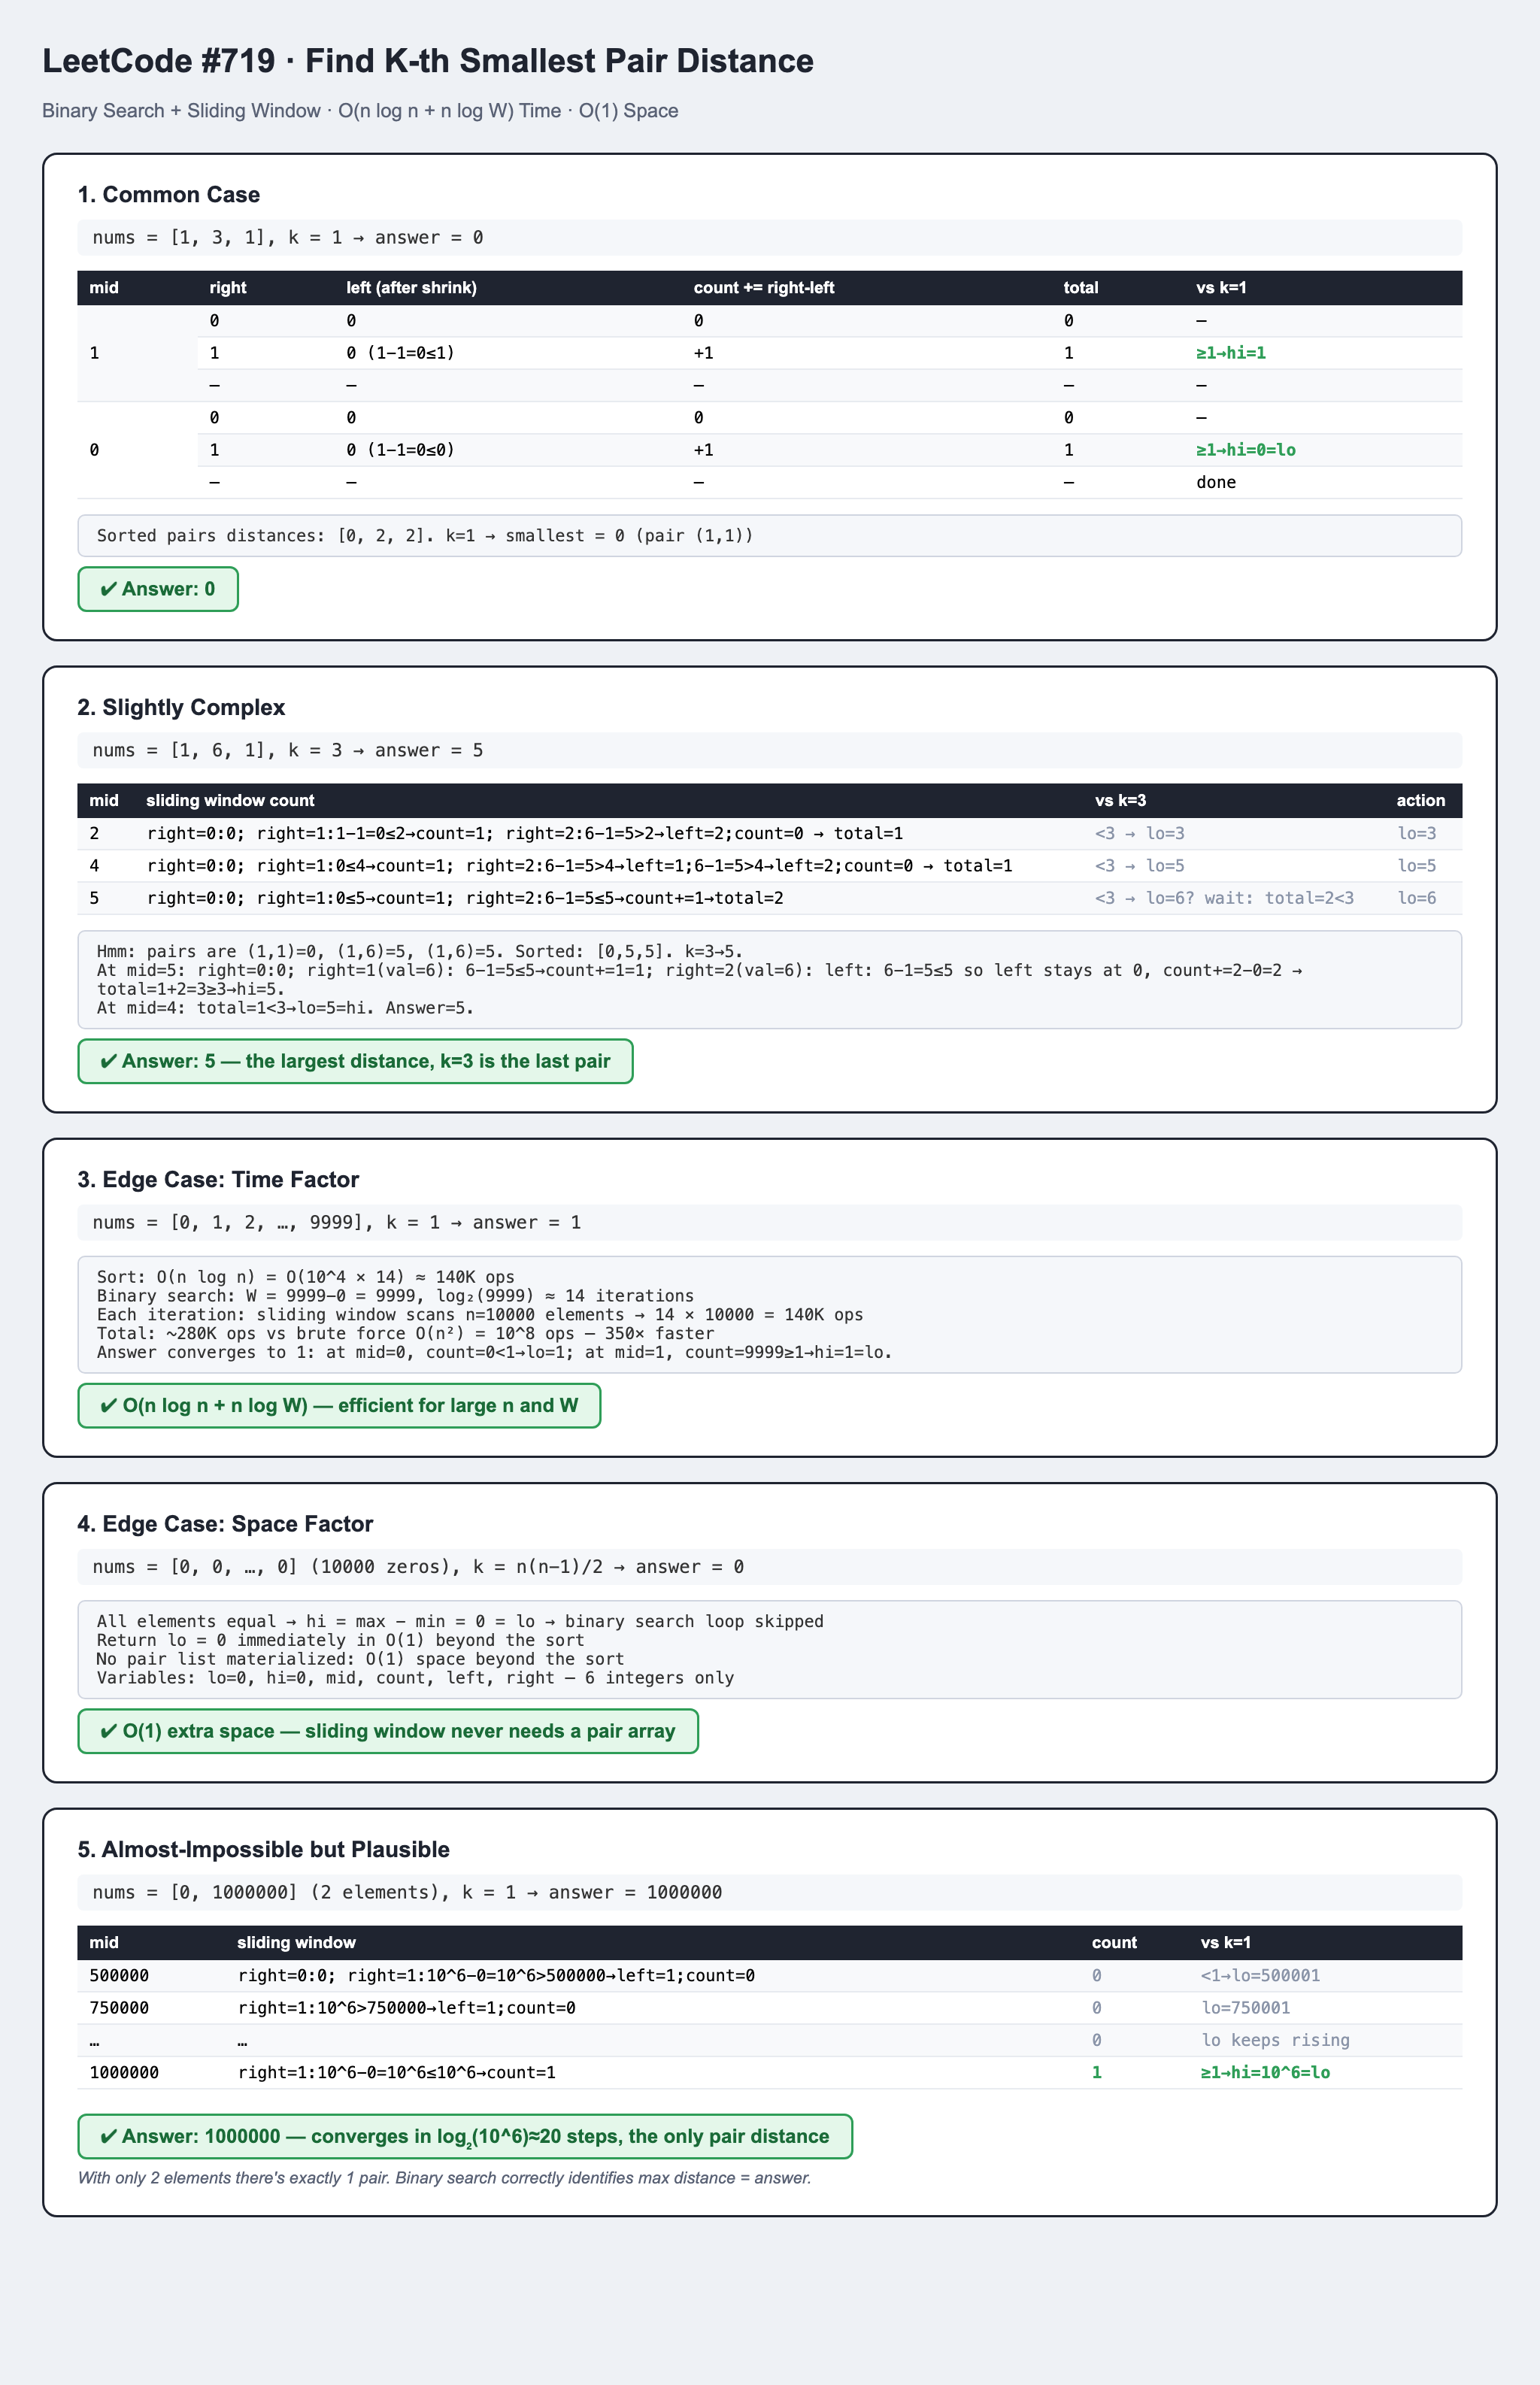